In [4]:
import spotipy
import json
from spotipy.oauth2 import SpotifyOAuth
from datetime import datetime, timedelta
import math 
import matplotlib
import spotipy
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import requests
from PIL import Image
from io import BytesIO



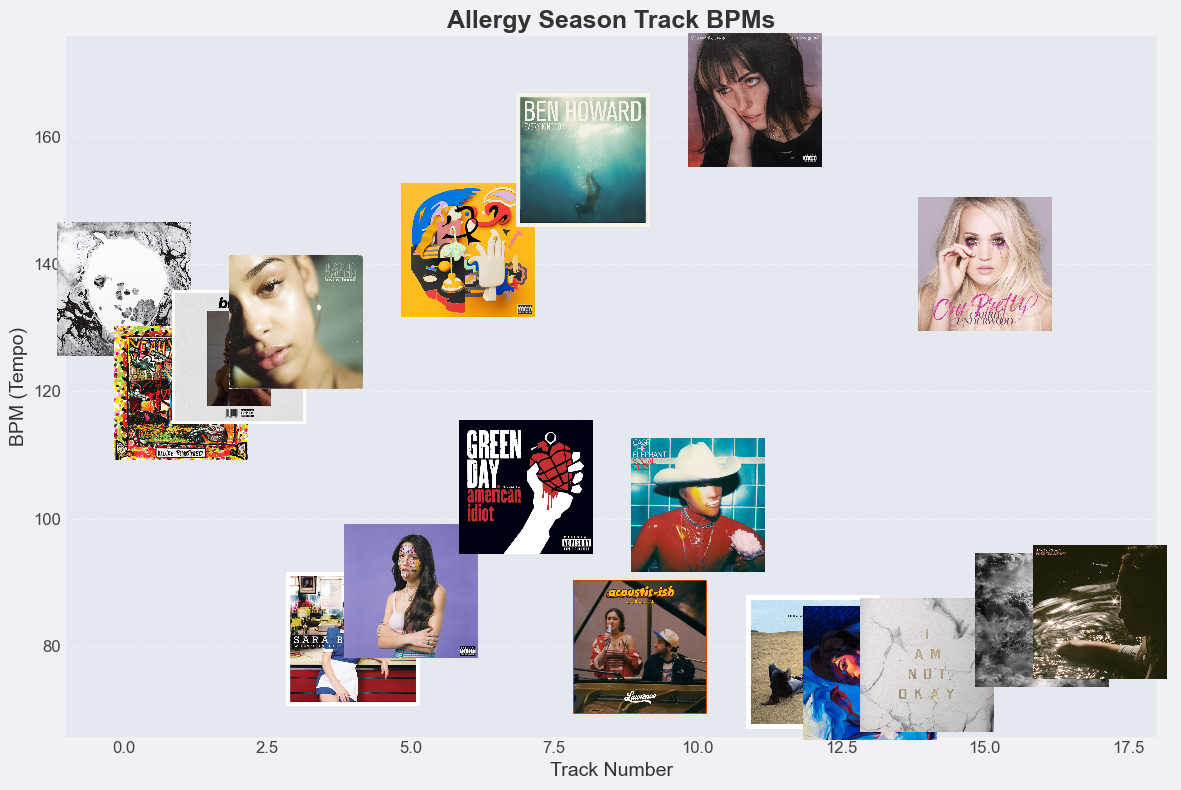

In [4]:


# Set up authentication
# Initialize the Spotify API client
sp = spotipy.Spotify(auth_manager=SpotifyOAuth(client_id="f6f6de34e09741d28b1766703ec2560a",
                                               client_secret="19cd0d5906204557934a27406a24e4ca",
                                               redirect_uri="http://localhost:8888/callback",
                                               scope="user-library-read playlist-modify-public playlist-read-private playlist-read",
                                               requests_timeout=30))

# Function to get all track IDs and cover art URLs from a playlist
def get_playlist_tracks_and_art(playlist_id):
    results = sp.playlist_items(playlist_id)
    tracks = results['items']
    while results['next']:
        results = sp.next(results)
        tracks.extend(results['items'])
    
    track_data = [(track['track']['id'], track['track']['album']['images'][0]['url']) 
                  for track in tracks if track['track']]  # Extract track IDs and cover art URLs
    return track_data

# Function to get BPM (tempo) for each track
def get_track_tempos(track_ids):
    tempos = []
    for i in range(0, len(track_ids), 100):  # Can retrieve max 100 tracks per request
        audio_features = sp.audio_features(track_ids[i:i+100])
        tempos.extend([track['tempo'] for track in audio_features if track])
    return tempos

# Function to add cover art images at specific coordinates
def add_cover_art(ax, x, y, image_url):
    response = requests.get(image_url)
    img = Image.open(BytesIO(response.content))  # Open image with PIL
    img = img.convert("RGB")  # Ensure image is in RGB format
    img = OffsetImage(img, zoom=0.15)  # Adjust zoom to size the cover art
    ab = AnnotationBbox(img, (x, y), frameon=False)
    ax.add_artist(ab)

# Your playlist ID (replace with your playlist)
playlist_id = '4AZL34bwUEL6b0RikQjQRJ'

# Get track IDs and cover art URLs
track_data = get_playlist_tracks_and_art(playlist_id)
track_ids = [track[0] for track in track_data]  # Extract track IDs
cover_art_urls = [track[1] for track in track_data]  # Extract cover art URLs

# Get BPMs
tempos = get_track_tempos(track_ids)

# Set a stylish plot theme (optional: 'ggplot', 'seaborn-dark', 'fivethirtyeight')
plt.style.use('seaborn-v0_8-dark')

# Create figure and axis with a clean background and grid
fig, ax = plt.subplots(figsize=(12, 8), facecolor='#f0f0f5')
ax.set_facecolor('#eaeaf2')  # Set background color of the plot

# Customizing the axis
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#444444')
ax.spines['bottom'].set_color('#444444')
ax.tick_params(colors='#444444', labelsize=12)

# Customizing labels
ax.set_title('Allergy Season Track BPMs', fontsize=18, fontweight='bold', color='#333333')
ax.set_xlabel('Track Number', fontsize=14, color='#333333')
ax.set_ylabel('BPM (Tempo)', fontsize=14, color='#333333')

# Adjust the range and ticks
ax.set_xlim(-1, len(tempos))  # Adjust the x-axis limit
ax.set_ylim(min(tempos) - 10, max(tempos) + 10)  # Adjust the y-axis limit

# Add grid with styling
ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.7, alpha=0.7)

# Plot cover art for each track at the BPM point
for i, tempo in enumerate(tempos):
    add_cover_art(ax, i, tempo, cover_art_urls[i])

# Add a gradient background to the y-axis
ax.axhspan(min(tempos) - 10, max(tempos) + 10, facecolor='#dde4eb', alpha=0.3)

# Show plot
plt.tight_layout()
#plt.savefig('playlist_bpm_plot.png', format='png', dpi=300)  # Save the plot as a PNG file

plt.show()


In [18]:
print(plt.style.available)


['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [33]:
def gtt(track_ids):
    tempos = []
    for i in range(0, len(track_ids), 100):  # Can retrieve max 100 tracks per request
        audio_features = sp.audio_features(track_ids[i:i+100])
        tempos.extend([track['tempo'] for track in audio_features if track])
    return audio_features

gtt(['5ebtxZRrC1JQvZ1HCAiLYv'])

[{'danceability': 0.625,
  'energy': 0.54,
  'key': 11,
  'loudness': -9.059,
  'mode': 1,
  'speechiness': 0.0271,
  'acousticness': 0.113,
  'instrumentalness': 0.162,
  'liveness': 0.107,
  'valence': 0.492,
  'tempo': 165.909,
  'type': 'audio_features',
  'id': '5ebtxZRrC1JQvZ1HCAiLYv',
  'uri': 'spotify:track:5ebtxZRrC1JQvZ1HCAiLYv',
  'track_href': 'https://api.spotify.com/v1/tracks/5ebtxZRrC1JQvZ1HCAiLYv',
  'analysis_url': 'https://api.spotify.com/v1/audio-analysis/5ebtxZRrC1JQvZ1HCAiLYv',
  'duration_ms': 182400,
  'time_signature': 4}]

In [12]:

# Set up authentication
# Initialize the Spotify API client
sp = spotipy.Spotify(auth_manager=SpotifyOAuth(client_id="f6f6de34e09741d28b1766703ec2560a",
                                               client_secret="19cd0d5906204557934a27406a24e4ca",
                                               redirect_uri="http://localhost:8888/callback",
                                               scope="user-library-read playlist-modify-public playlist-read-private playlist-read user-follow-read",
                                               requests_timeout=30))

sp.current_user_follow_playlist(playlist_id)

HTTP Error for PUT to https://api.spotify.com/v1/playlists/4AZL34bwUEL6b0RikQjQRJ/followers with Params: {} returned 403 due to Insufficient client scope


SpotifyException: http status: 403, code:-1 - https://api.spotify.com/v1/playlists/4AZL34bwUEL6b0RikQjQRJ/followers:
 Insufficient client scope, reason: None